Mounted at /content/drive
✅ Libraries loaded
✅ Config loaded
   Datasets     : 11
   Train/Test   : 70% / 30%
   n_neighbors  : 5
   weights      : distance
   metric       : euclidean
  KNN — K Sensitivity Analysis (finding best K per dataset)

  AAC        → K=1:0.560  K=3:0.594  K=5:0.574  K=7:0.592  K=9:0.606  K=11:0.616  K=13:0.619  K=15:0.618
             Best K = 13  (AUC=0.6191)

  DPC        → K=1:0.634  K=3:0.668  K=5:0.652  K=7:0.637  K=9:0.635  K=11:0.636  K=13:0.640  K=15:0.642
             Best K = 3  (AUC=0.6684)

  CTDC       → K=1:0.522  K=3:0.555  K=5:0.570  K=7:0.572  K=9:0.564  K=11:0.569  K=13:0.555  K=15:0.552
             Best K = 7  (AUC=0.5724)

  CTDT       → K=1:0.561  K=3:0.574  K=5:0.540  K=7:0.532  K=9:0.540  K=11:0.543  K=13:0.548  K=15:0.547
             Best K = 3  (AUC=0.5737)

  GAAC       → K=1:0.566  K=3:0.612  K=5:0.626  K=7:0.636  K=9:0.645  K=11:0.641  K=13:0.651  K=15:0.648
             Best K = 13  (AUC=0.6514)

  PAAC       → K=1:0.602  K=3:0.

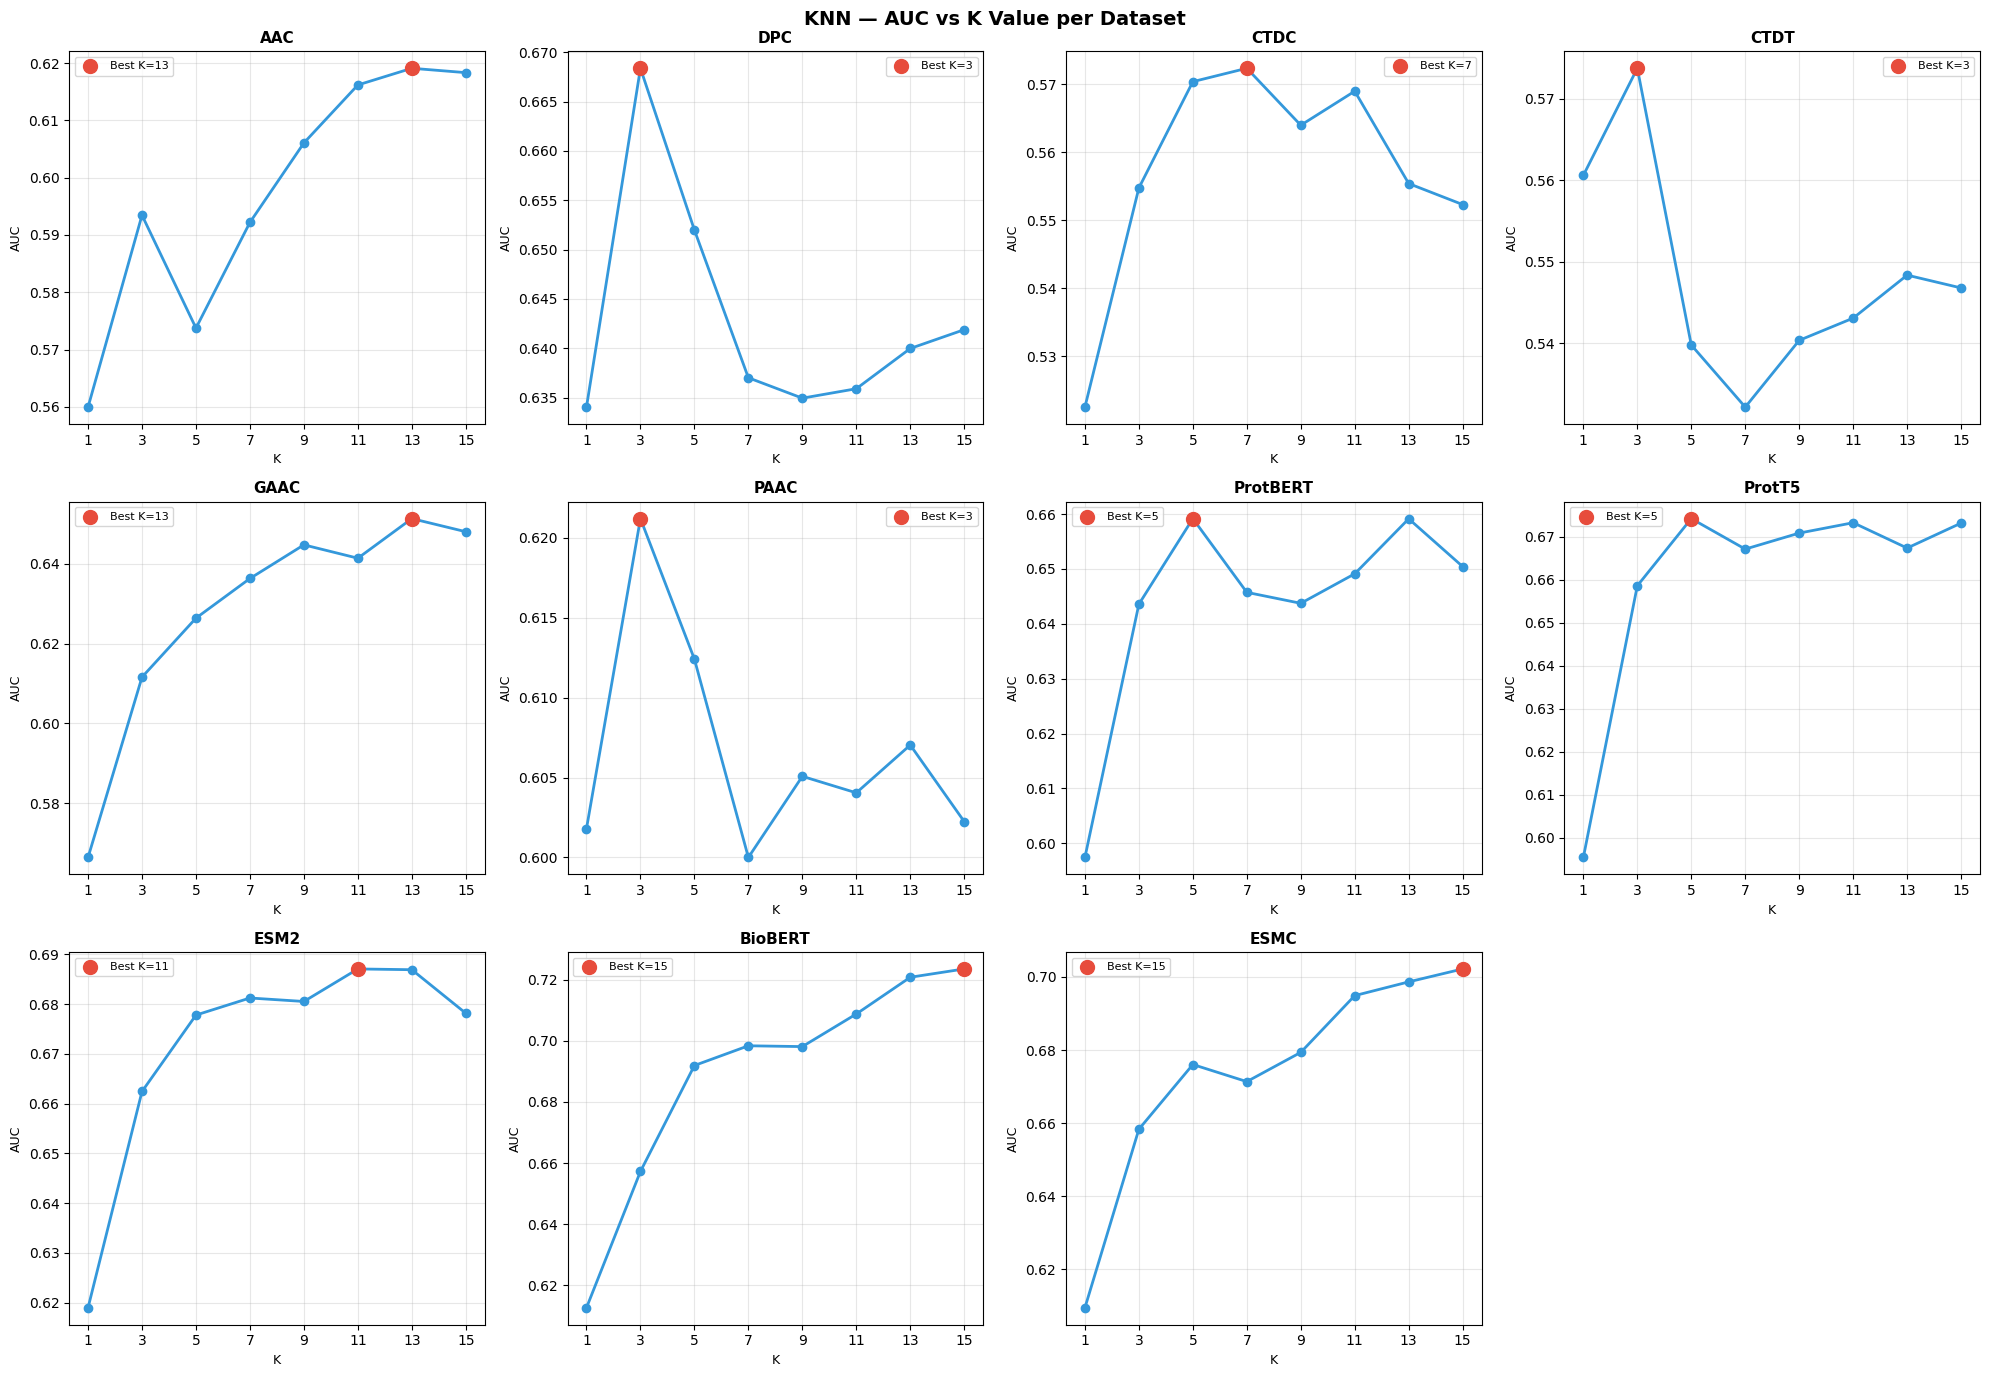

✅ K sensitivity plot saved
  KNN — Training & Evaluation on 11 Datasets (best K each)

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  K used  : 13

  ── Results ──────────────────────────────────────
  Accuracy    : 0.6012
  Sensitivity : 0.5513
  Specificity : 0.6345
  F1 Score    : 0.5254
  MCC         : 0.1834
  AUC         : 0.6191
  TP=145  TN=250  FP=144  FN=118
  Probabilities saved → /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/knn/AAC_KNN_probabilities.csv

────────────────────────────────────────────────────────────
  Dataset : DPC  (DPC_features.csv)
  Shape   : (2190, 401)  |  Features: 400  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  K used  : 3

  ── Results ──────────────────────────────────────
  Accuracy    : 0.5434
  Sensitivity : 0.8289
  Specificity : 0.3528
  F

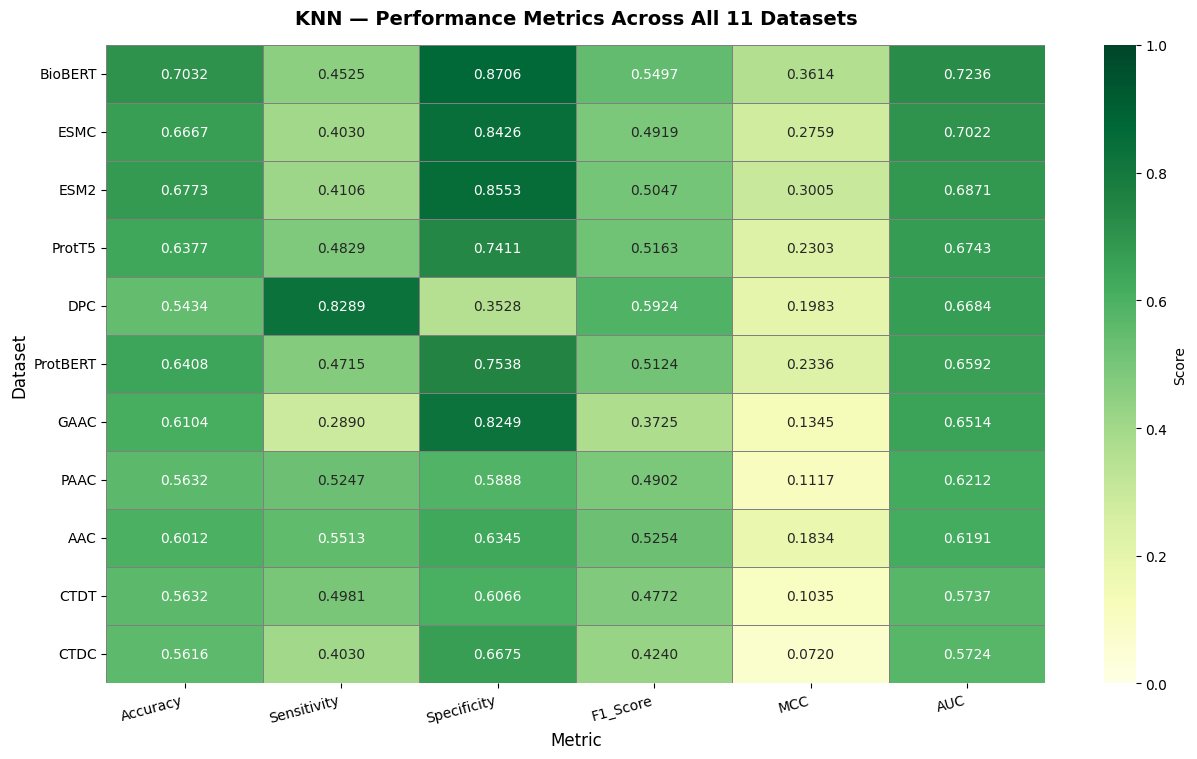

✅ Metrics heatmap saved


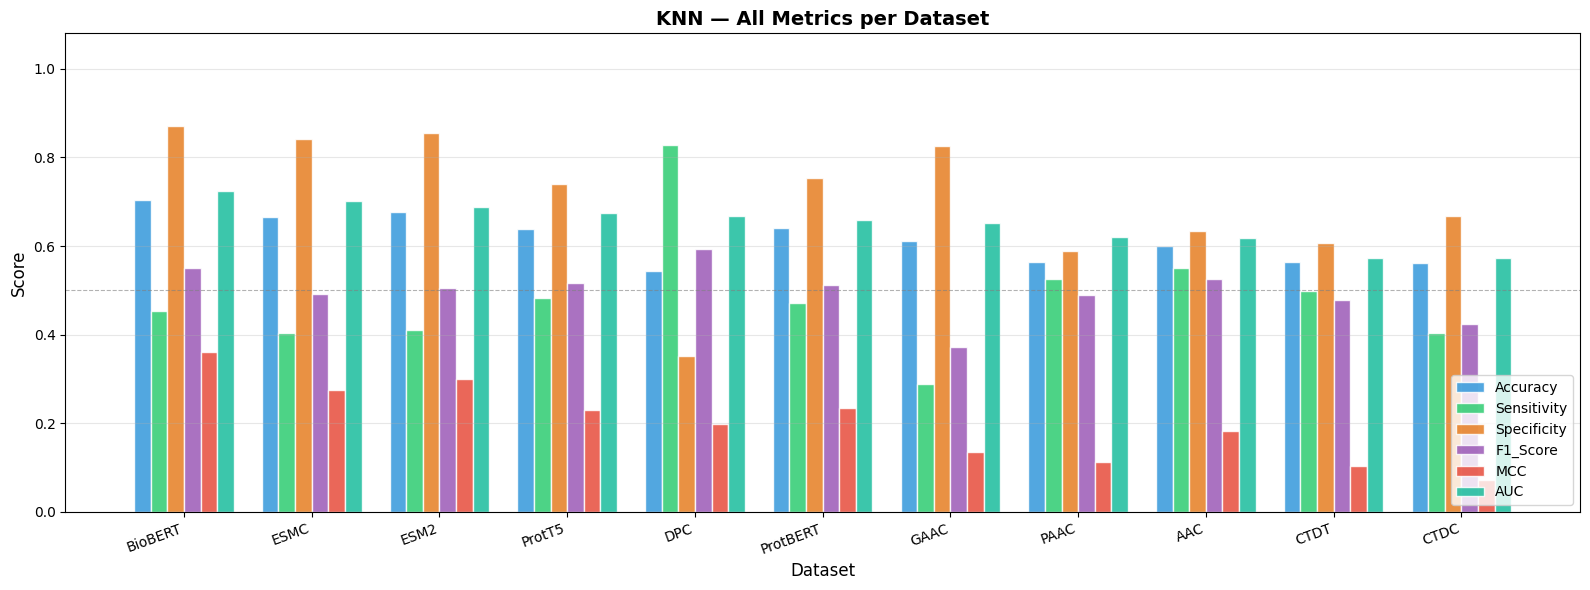

✅ Grouped bar chart saved


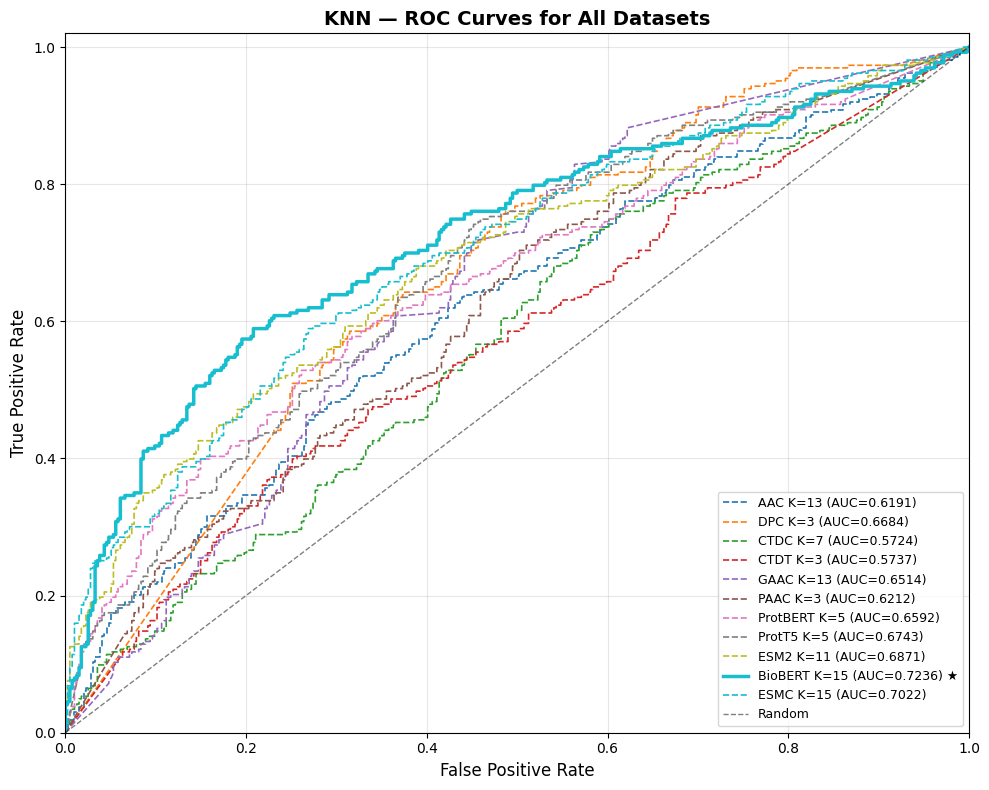

✅ ROC curves saved


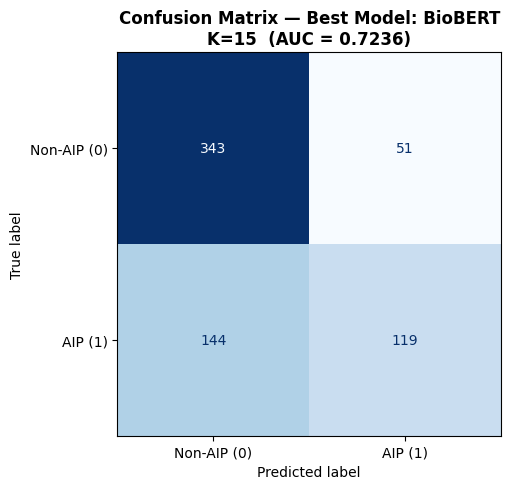

✅ Confusion matrix saved (BioBERT)


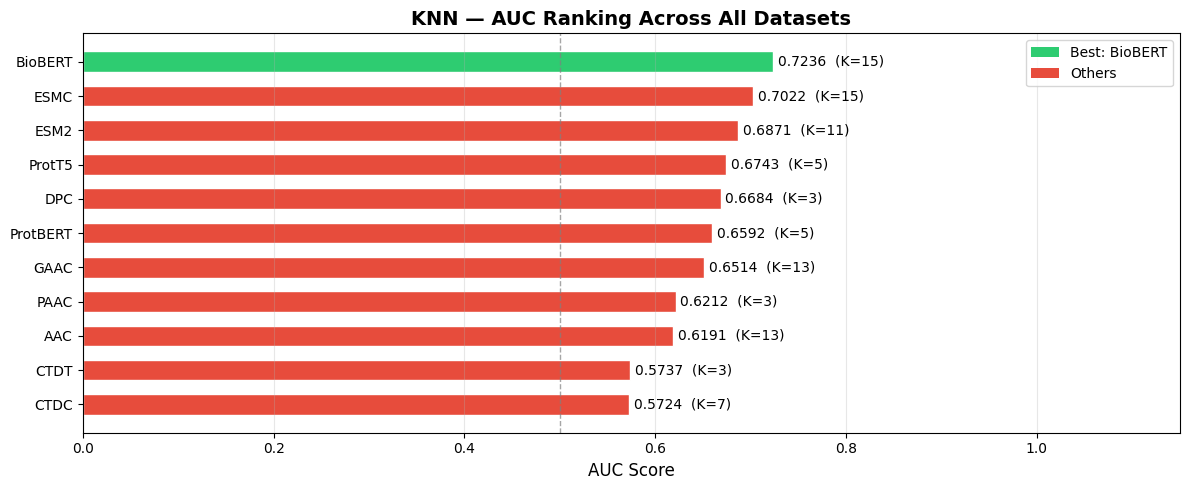

✅ AUC ranking chart saved
  KNN — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/knn
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/knn
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/knn

─────────────────────────────────────────────────────────────────
  Dataset         K      Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  BioBERT        15   0.7032   0.4525   0.8706   0.5497   0.3614   0.7236 ★
  ESMC           15   0.6667   0.4030   0.8426   0.4919   0.2759   0.7022
  ESM2           11   0.6773   0.4106   0.8553   0.5047   0.3005   0.6871
  ProtT5          5   0.6377   0.4829   0.7411   0.5163   0.2303   0.6743
  DPC             3   0.5434   0.8289   0.3528   0.5924   0.1983   0.6684
  ProtBERT        5   0.6408   0.4715   0.7538   0.5124   0.2336   0.6592
  GAAC           13   0.610

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/knn"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/knn"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/knn"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── KNN hyperparameters ──────────────────────────────────────
#
#  Key KNN parameters:
#    n_neighbors  : number of nearest neighbours to vote
#                   odd number avoids ties; 5 is standard default
#                   for small datasets (< 1000) try 3, 5, 7, 9
#    weights      : "uniform"  — all neighbours vote equally
#                   "distance" — closer neighbours vote more ✅ better
#    metric       : distance metric used to find neighbours
#                   "euclidean" — straight-line distance (default)
#                   "manhattan" — L1, robust to outliers
#                   "cosine"    — recommended for PLM embeddings
#                                 (high-dimensional vectors)
#    algorithm    : "auto" lets sklearn pick the fastest tree structure
#    n_jobs       : -1 uses all CPU cores
#
#  ⚠️  KNN is sensitive to feature scale — StandardScaler is critical.
#  ⚠️  KNN has no built-in class imbalance handling.
#      We use weighted voting (weights="distance") to partially
#      mitigate this; further mitigation via stratified split.
#
KNN_PARAMS = {
    "n_neighbors": 5,
    "weights"    : "distance",    # "uniform" or "distance"
    "metric"     : "euclidean",   # "euclidean", "manhattan", "cosine"
    "algorithm"  : "auto",
    "n_jobs"     : -1,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets     : {len(DATASETS)}")
print(f"   Train/Test   : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   n_neighbors  : {KNN_PARAMS['n_neighbors']}")
print(f"   weights      : {KNN_PARAMS['weights']}")
print(f"   metric       : {KNN_PARAMS['metric']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — K Sensitivity Analysis
#            Find the best K for each dataset before full run
#            Tests odd K values: 1, 3, 5, 7, 9, 11, 13, 15
# ============================================================

print("=" * 65)
print("  KNN — K Sensitivity Analysis (finding best K per dataset)")
print("=" * 65)

K_VALUES      = [1, 3, 5, 7, 9, 11, 13, 15]
best_k_per_ds = {}    # will store best K found per dataset

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    k_aucs = {}
    for k in K_VALUES:
        knn = KNeighborsClassifier(
            n_neighbors = k,
            weights     = KNN_PARAMS["weights"],
            metric      = KNN_PARAMS["metric"],
            algorithm   = KNN_PARAMS["algorithm"],
            n_jobs      = KNN_PARAMS["n_jobs"],
        )
        knn.fit(X_train, y_train)
        y_prob_k    = knn.predict_proba(X_test)[:, 1]
        k_aucs[k]   = round(roc_auc_score(y_test, y_prob_k), 4)

    best_k = max(k_aucs, key=k_aucs.get)
    best_k_per_ds[ds_name] = best_k

    k_str = "  ".join([f"K={k}:{v:.3f}" for k, v in k_aucs.items()])
    print(f"\n  {ds_name:<10} → {k_str}")
    print(f"             Best K = {best_k}  (AUC={k_aucs[best_k]:.4f})")

print(f"\n✅ K sensitivity complete")
print(f"   Best K per dataset: {best_k_per_ds}")


# ============================================================
#   CELL 6 — K Sensitivity Plot
# ============================================================

fig, axes = plt.subplots(
    3, 4, figsize=(20, 14), sharey=False
)
axes = axes.flatten()

for idx, (ds_name, csv_file) in enumerate(DATASETS.items()):

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        axes[idx].set_visible(False)
        continue

    ax = axes[idx]
    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    k_aucs = []
    for k in K_VALUES:
        knn = KNeighborsClassifier(
            n_neighbors=k, weights=KNN_PARAMS["weights"],
            metric=KNN_PARAMS["metric"], n_jobs=-1
        )
        knn.fit(X_train, y_train)
        y_prob_k = knn.predict_proba(X_test)[:, 1]
        k_aucs.append(roc_auc_score(y_test, y_prob_k))

    best_k  = best_k_per_ds.get(ds_name, 5)
    best_idx = K_VALUES.index(best_k)

    ax.plot(K_VALUES, k_aucs, "o-", color="#3498db",
            linewidth=2, markersize=6)
    ax.scatter([best_k], [k_aucs[best_idx]],
               color="#e74c3c", s=100, zorder=5,
               label=f"Best K={best_k}")
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("K", fontsize=9)
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(DATASETS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("KNN — AUC vs K Value per Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "KNN_K_sensitivity.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ K sensitivity plot saved")


# ============================================================
#   CELL 7 — Main Training Loop (using best K per dataset)
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  KNN — Training & Evaluation on 11 Datasets (best K each)")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    # ⚠️ Critical for KNN — distances are meaningless without scaling
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Use best K found in sensitivity analysis ──────────────
    k_used = best_k_per_ds.get(ds_name, KNN_PARAMS["n_neighbors"])
    print(f"  K used  : {k_used}")

    # ── Train KNN ────────────────────────────────────────────
    clf = KNeighborsClassifier(
        n_neighbors = k_used,
        weights     = KNN_PARAMS["weights"],
        metric      = KNN_PARAMS["metric"],
        algorithm   = KNN_PARAMS["algorithm"],
        n_jobs      = KNN_PARAMS["n_jobs"],
    )
    clf.fit(X_train, y_train)

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]  = ds_name
    metrics["Features"] = X.shape[1]
    metrics["K_used"]   = k_used
    metrics["Train_N"]  = len(X_train)
    metrics["Test_N"]   = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR, f"{ds_name}_KNN_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "clf"   : clf,
        "scaler": scaler,
        "k"     : k_used,
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 8 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "K_used", "Accuracy", "Sensitivity",
               "Specificity", "F1_Score", "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── KNN Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "KNN_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 9 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR, f"KNN_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR, f"KNN_best_scaler_{best_name}.joblib")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

print(f"✅ Best model saved")
print(f"   Dataset : {best_name}")
print(f"   K used  : {best_k_per_ds.get(best_name)}")
print(f"   AUC     : {best_auc:.4f}")
print(f"   Model   : {best_model_path}")
print(f"   Scaler  : {best_scaler_path}")


# ============================================================
#   CELL 10 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity", "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("KNN — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "KNN_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 11 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("KNN — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "KNN_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 12 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} K={data['k']} (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("KNN — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "KNN_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 13 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"K={best_k_per_ds.get(best_name)}  "
             f"(AUC = {best_auc:.4f})",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"KNN_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 14 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df  = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val, k in zip(bars, sorted_df["AUC"], sorted_df["K_used"]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}  (K={k})", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("KNN — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.15)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "KNN_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 15 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  KNN — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'K':>4} {'Acc':>8} {'Sn':>8} {'Sp':>8} "
      f"{'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {int(row['K_used']):>4} "
          f"{row['Accuracy']:>8.4f} "
          f"{row['Sensitivity']:>8.4f} {row['Specificity']:>8.4f} "
          f"{row['F1_Score']:>8.4f} {row['MCC']:>8.4f} "
          f"{row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset : {best_name}")
print(f"     K used       : {best_k_per_ds.get(best_name)}")
print(f"     Accuracy     : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity  : {best_row['Sensitivity']:.4f}")
print(f"     Specificity  : {best_row['Specificity']:.4f}")
print(f"     F1 Score     : {best_row['F1_Score']:.4f}")
print(f"     MCC          : {best_row['MCC']:.4f}")
print(f"     AUC          : {best_row['AUC']:.4f}")
print(f"\n  KNN notes:")
print(f"     ✅ Non-parametric — no model training, stores all data")
print(f"     ✅ Best K selected per dataset via AUC sweep")
print(f"     ⚠️  Slow on high-dim PLM features (768–1280 dims)")
print(f"     ⚠️  StandardScaler is critical — distances need scaling")
print("=" * 65)